# Complete Data Analysis Pipeline

**Workflow for loading and analyzing all datasets:**
- **ASOS**: Airport weather stations
- **Weather Underground**: Personal weather stations
- **OpenMesh**: CML links and PWS data

**Features:**
- Load from files or fetch from APIs
- Unified format conversion
- Visualization and comparison
- Advanced multipanel plots with matched sensors

## 1. Setup & Imports

Import required libraries and analysis functions for data processing, visualization, and analysis.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from datetime import datetime
import sys
import warnings
warnings.filterwarnings('ignore')

# Add project root to path.
sys.path.insert(0, str(Path.cwd().parent))

# Import all pipeline functions (from data_pipeline.py).
from analysis.pipeline import *
from analysis.analysis_functions import *
from analysis.plotting import *
print("✓ Setup complete")

✓ Setup complete


## 2. Configuration

Set analysis parameters including date range, station selections, and data acquisition mode (load from files or fetch from APIs).

In [34]:
# ============================================================================
# CONFIGURATION
# ============================================================================

# Analysis period
START_DATE = datetime(2024, 1, 1)
END_DATE   = datetime(2024, 1, 30)

# Stations to analyze
ASOS_STATIONS = ['KLGA', 'KNYC', 'KJFK']  # Not JFK
WU_STATIONS = 'all'  # 'all' or list of station IDs

# Mode: 'load' or 'fetch' :
MODE      =   'load'  
# 'load'  = load from files
# 'fetch' = fetch from APIs

print(  "=" * 70)
print(  "CONFIGURATION")
print(  "=" * 70)
print(  f"Period: {START_DATE.date()} → {END_DATE.date()}")
print(  f"Mode: {MODE.upper()}")
print(  f"ASOS stations: {ASOS_STATIONS}")
print(  f"WU stations: {WU_STATIONS}")
print(  "=" * 70)

CONFIGURATION
Period: 2024-01-01 → 2024-01-30
Mode: LOAD
ASOS stations: ['KLGA', 'KNYC', 'KJFK']
WU stations: all


## 3. Load Metadata

Load metadata files for ASOS stations, Weather Underground PWS stations, and OpenMesh CML links.

In [35]:
# Load all metadata files
paths       = get_default_paths()
metadata    = load_metadata(paths)

print(  "\nMetadata loaded:"    )
print(f"  ASOS: {len(metadata['asos'])} stations")
print(f"  WU: {len(metadata['wu'])} stations")
print(f"  OpenMesh Links: {len(metadata['openmesh_links'])} sublinks")

LOADING METADATA
✓ ASOS: 3 stations
✓ WU: 37 stations
✓ OpenMesh Links: 103 sublinks

Metadata loaded:
  ASOS: 3 stations
  WU: 37 stations
  OpenMesh Links: 103 sublinks


## 4. Load/Fetch Weather Data (ASOS & WU)

Load or fetch weather data from ASOS (Airport weather stations) and Weather Underground (Personal weather stations) for the specified date range and stations.

In [36]:
# Load or fetch ASOS and WU data.

weather_data = load_or_fetch_data(
    mode            = MODE,
    start_date      = START_DATE,
    end_date        = END_DATE,
    acquire_asos    = True,
    acquire_wu      = True,
    asos_stations   = ASOS_STATIONS,
    wu_stations     = WU_STATIONS if WU_STATIONS != 'all' else None,
    asos_metadata   = metadata['asos'],
    wu_metadata     = metadata['wu'],
    paths           = paths
)

print("\n" + "=" * 70)
print("LOADED DATA SUMMARY")
print("=" * 70)
print(f"ASOS: {len(weather_data['asos'])} stations")
print(f"WU: {len(weather_data['wu'])} stations")
print("=" * 70)

DATA ACQUISITION: LOAD
Period: 2024-01-01 → 2024-01-30

📁 ASOS
  Folder: /Users/drorjac/PycharmProjects/OpenMesh-fresh/dataset/raw/fetched/asos
  Available files (1):
    - standard_2024-01-01_2024-01-29.csv
  ⚠ No exact match for 2024-01-01_2024-01-30
  ✓ Using best match: standard_2024-01-01_2024-01-29.csv
    Date difference: 1 days, Stations: 3

📁 WU
  Folder: /Users/drorjac/PycharmProjects/OpenMesh-fresh/dataset/raw/fetched/wu
Found 1 WU file(s)
----------------------------------------------------------------------
Loading: WU_2024-01-01_2024-01-30.csv... ✓ 1 stations, 720 total rows

✓ Selected: 2024-01-01_2024-01-30 (exact match)
  Stations: ['KNYNEWYO1805']
  ✓ File: WU_2024-01-01_2024-01-30.csv

✓ ASOS: 3 stations
✓ WU: 1 stations

LOADED DATA SUMMARY
ASOS: 3 stations
WU: 1 stations


## 5. Load OpenMesh Data (CML & PWS)

Load OpenMesh Commercial Microwave Link (CML) data and associated PWS data from NetCDF files and metadata.

In [37]:
# Load OpenMesh CML links
ds_links, links_meta = load_openmesh_cml(
    cml_file=paths['openmesh_raw'] / 'ds_openmesh.nc',
    metadata_file=paths['openmesh_meta'] / 'links_metadata.csv'
)

# Load OpenMesh PWS data
# Choose: 'sample' = January data only (Zenodo-ESSD), 'full' = complete dataset (Zenodo-2)
PWS_FILE_TYPE = 'sample'  # Change to 'full' for complete dataset
pws_data = load_pws_from_netcdf(file_type=PWS_FILE_TYPE)

print("\n" + "=" * 70)
print("OPENMESH DATA LOADED")
print("=" * 70)
print(f"CML Links: {len(ds_links.cml_id)} links")
print(f"PWS Stations: {len(pws_data)} stations")
print("=" * 70)

Loading OpenMesh CML data from: /Users/drorjac/PycharmProjects/OpenMesh-fresh/dataset/raw/openmesh/ds_openmesh.nc
  ✓ Loaded CML dataset:
    Links: 75
    Time range: 2023-10-29 00:00:00 to 2024-07-01 00:00:00
    Time points: 354,241
  ✓ Loaded metadata: 103 sublinks
Loading SAMPLE PWS data from NetCDF: /Users/drorjac/PycharmProjects/OpenMesh-fresh/dataset/raw/openmesh/pws_opensense_sample_jan.nc
  Found 37 stations
    ✓ KNYNEWYO1472: 4,402 records
    ✓ KNYNEWYO1659: 4,606 records
    ... and 35 more stations

OPENMESH DATA LOADED
CML Links: 75 links
PWS Stations: 37 stations


## 6. Consolidate Datasets

Combine all loaded datasets (ASOS, WU, and OpenMesh) into a unified structure for analysis.

In [38]:
# Consolidate all datasets
datasets = {
    'asos': {'raw': weather_data['asos']},
    'wu': {'raw': weather_data['wu']},
    'openmesh': {
        'raw': {
            'links': ds_links,
            'pws': pws_data
        },
        'meta': {
            'links': links_meta
        }
    }
}

# Prepare analysis data with dynamic parameter extraction
# pws_source:
# ='openmesh' means that the PWS data is from the OpenMesh dataset, 
# 'wu' means that the PWS data is fetched from historical Weather Underground dataset (lower resolution).
analysis_data = prepare_analysis_data(
    datasets=datasets,
    analysis_period=(START_DATE, END_DATE),
    pws_source='openmesh',  # or 'wu':
    parameters='all',  # or ['rainfall_amount', 'temperature']
    # target_interval='5min'  # Resample to 5-minute intervals
)
print("\n✓ Analysis data prepared")

PREPARING ANALYSIS DATA (DYNAMIC)
PWS Source: openmesh
Parameters: all
Target interval: None (no resampling - original data)

📊 Selecting PWS data source: openmesh
  ✓ Using OpenMesh PWS: 37 stations

📅 Determining analysis period...
  Available time ranges:
    ASOS: 2024-01-01 → 2024-01-29
    PWS: 2024-01-15 → 2024-01-30
    CML: 2023-10-29 → 2024-07-01
  ✓ Using specified: 2024-01-01 → 2024-01-30

📊 Processing ASOS (dynamic)...
  🔍 Parameter mapping: 'precip_amount' → 'rainfall_amount'
  Discovered 10 parameters
    ✓ dewpoint: 3 stations
    ✓ wind_gust: 3 stations
    ✓ wind_speed: 3 stations
  🔍 JFK FINAL before concat (categorical): unique values=['NP', 'M ', '?3', 'P ', 'R-'], shape=(40240, 1)
  🔍 LGA FINAL before concat (categorical): unique values=['NP', 'M ', 'R-', '?3', 'P?'], shape=(41036, 1)
  🔍 NYC FINAL before concat (categorical): unique values=['NP', 'M', 'R-', 'P?', 'R '], shape=(34333, 1)
    🔄 Standardizing precip_type to 5 categories (dry/rain/snow/ice/mix)...
  

## 7. Map Sensors

Display sensor locations on an interactive map showing ASOS stations, Weather Underground PWS stations, and OpenMesh CML links.

✓ Filtered to 2 ASOS stations
✓ Matplotlib map created


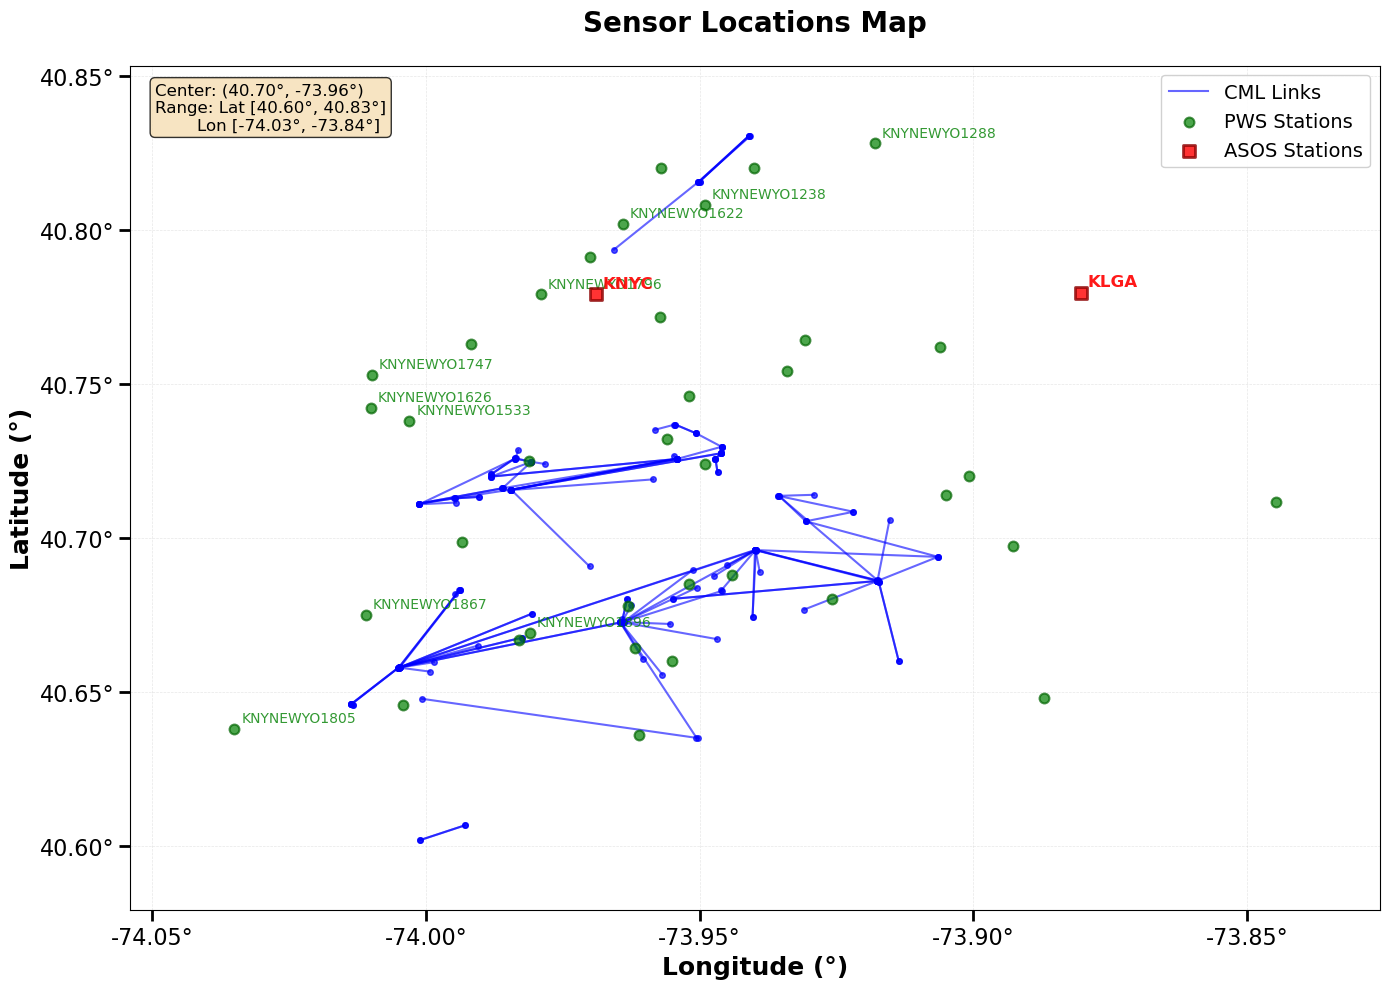

In [39]:

# Only show ASOS labels
fig, ax = display_sensors_map(
    links_meta=links_meta,
    asos_meta=metadata['asos'],
    pws_meta=metadata['wu'],
    map_type='matplotlib',
    show_link_labels=False,
    asos_station_ids=['KLGA', 'KNYC'],

    # show_pws_labels=False,
    # show_asos_labels=True  # Only ASOS
)

## 8. Display Weather Data

Visualize weather parameters including precipitation accumulation, rainfall amounts, and other meteorological variables from ASOS and PWS stations.

In [40]:


# Display weather info
display_weather_info()

# Set up same dates for NOAA - WU 
adjust_dates_flag = True

if adjust_dates_flag:
    original_start = START_DATE
    original_end = END_DATE
    
    START_DATE, END_DATE = adjust_dates(analysis_data, START_DATE, END_DATE)
    
    print(f"\n📅 Date Range Adjustment:")
    print(f"  Original: {original_start.date()} → {original_end.date()}")
    print(f"  Adjusted: {START_DATE.date()} → {END_DATE.date()}")
    print("=" * 70)


DISPLAY WEATHER
### Display Precipitation :

📅 Date Range Adjustment:
  Original: 2024-01-01 → 2024-01-30
  Adjusted: 2024-01-15 → 2024-01-29


  ℹ Showing first 10 of 37 PWS stations


(<Figure size 1600x800 with 2 Axes>,
 array([<Axes: title={'center': 'ASOS - Temperature (°C) (3 stations)'}, ylabel='Temperature (°C)'>,
        <Axes: title={'center': 'PWS - Temperature (°C) (37 stations)'}, xlabel='Time', ylabel='Temperature (°C)'>],
       dtype=object))

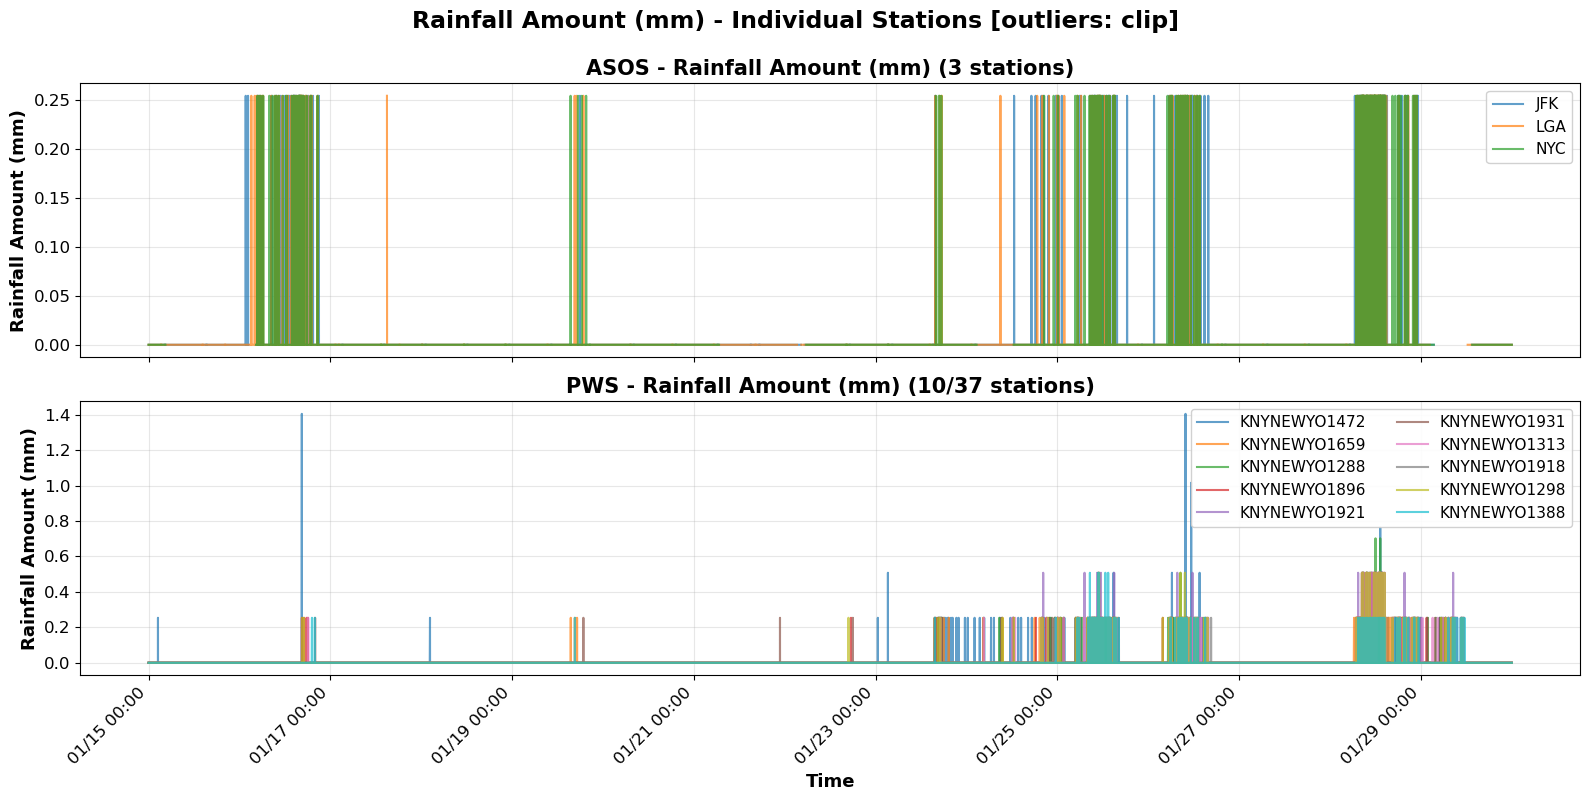

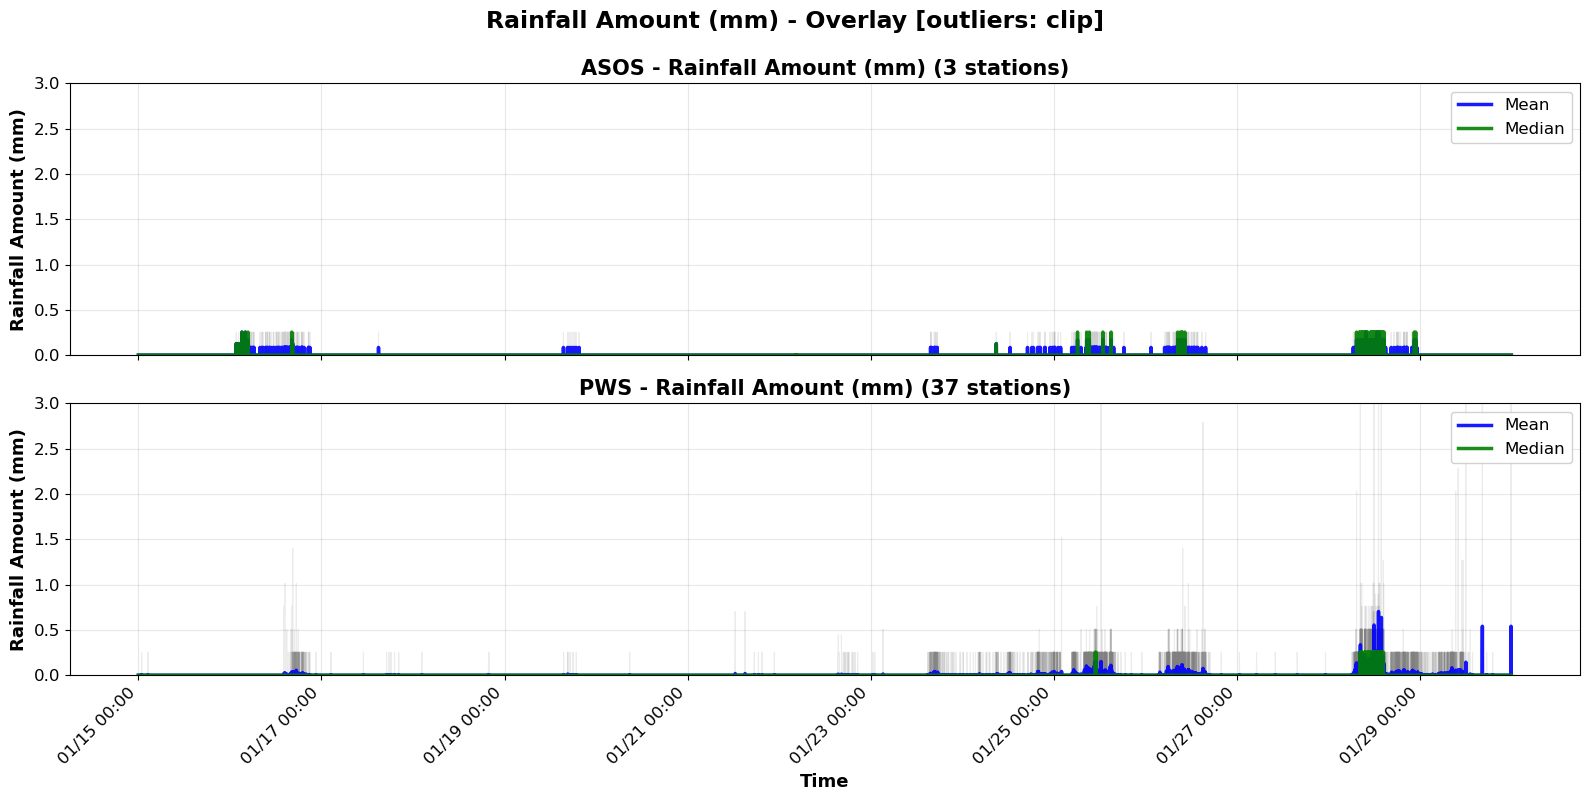

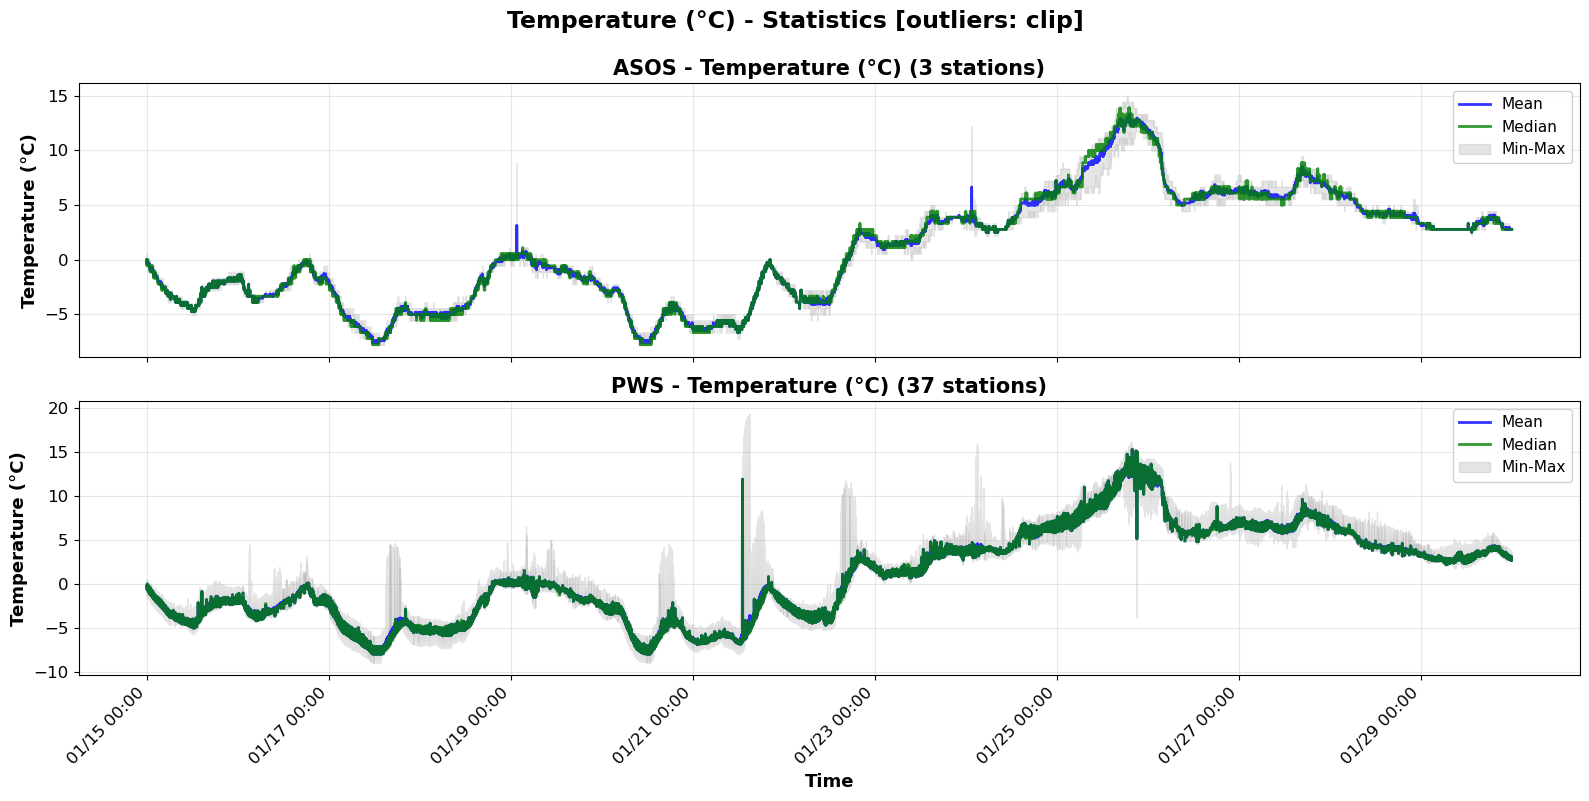

In [41]:


plot_weather_params(
    analysis_data,
    parameter='rainfall_amount',
    mode='raw',
    max_stations=10,
    start_date=START_DATE,
    end_date=END_DATE

)
# Overlay mode with y-limit
plot_weather_params(
    analysis_data,
    parameter='rainfall_amount',
    mode='overlay', 
    ylim=3,  # Max 5mm
    start_date=START_DATE,
    end_date=END_DATE
)

###
plot_weather_params(
    analysis_data,
    parameter='temperature',
    start_date=START_DATE,
    end_date=END_DATE,
        mode='stats',  

)




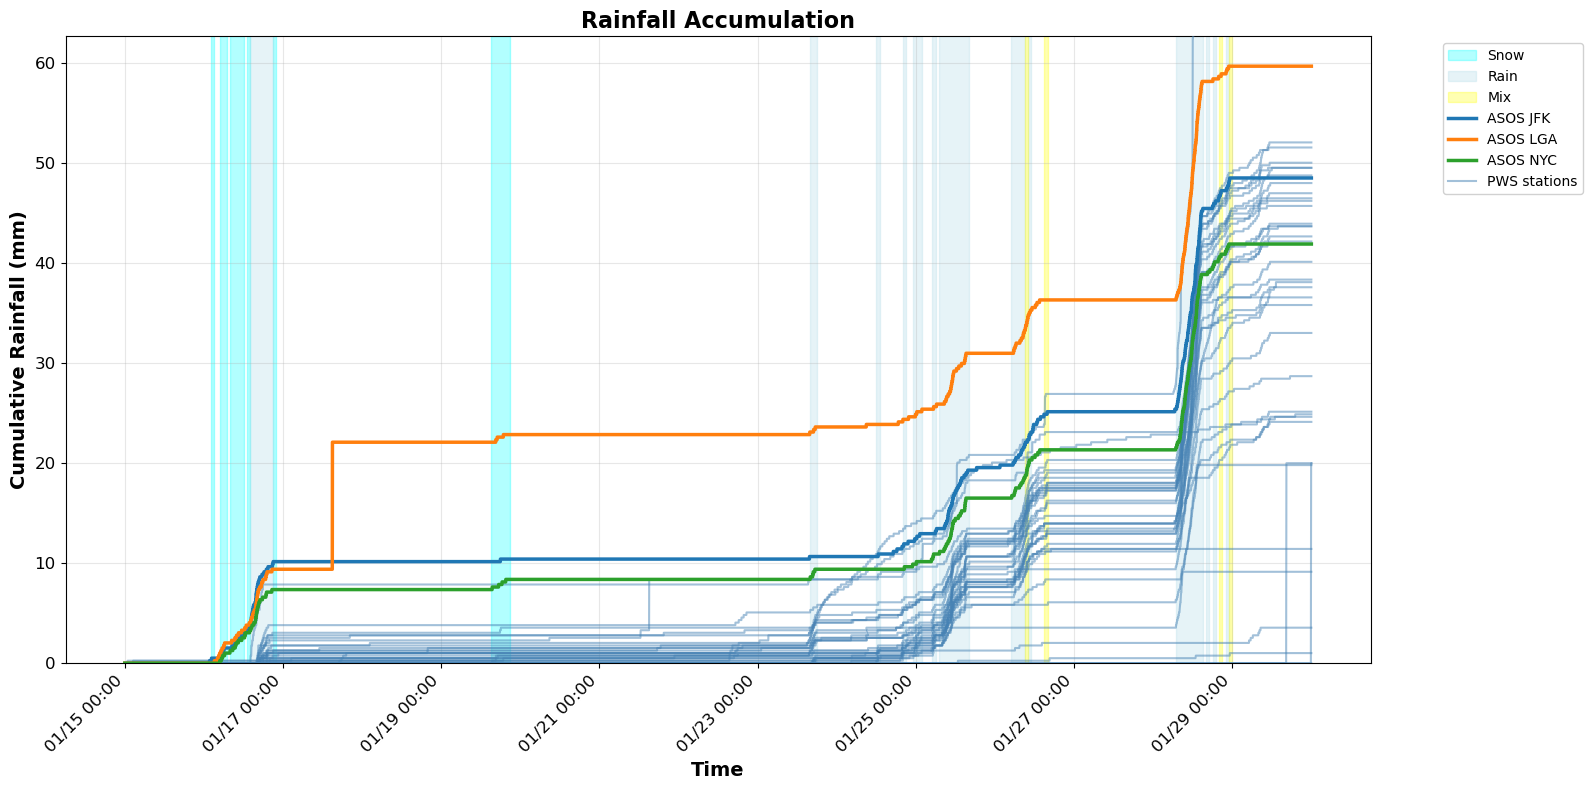

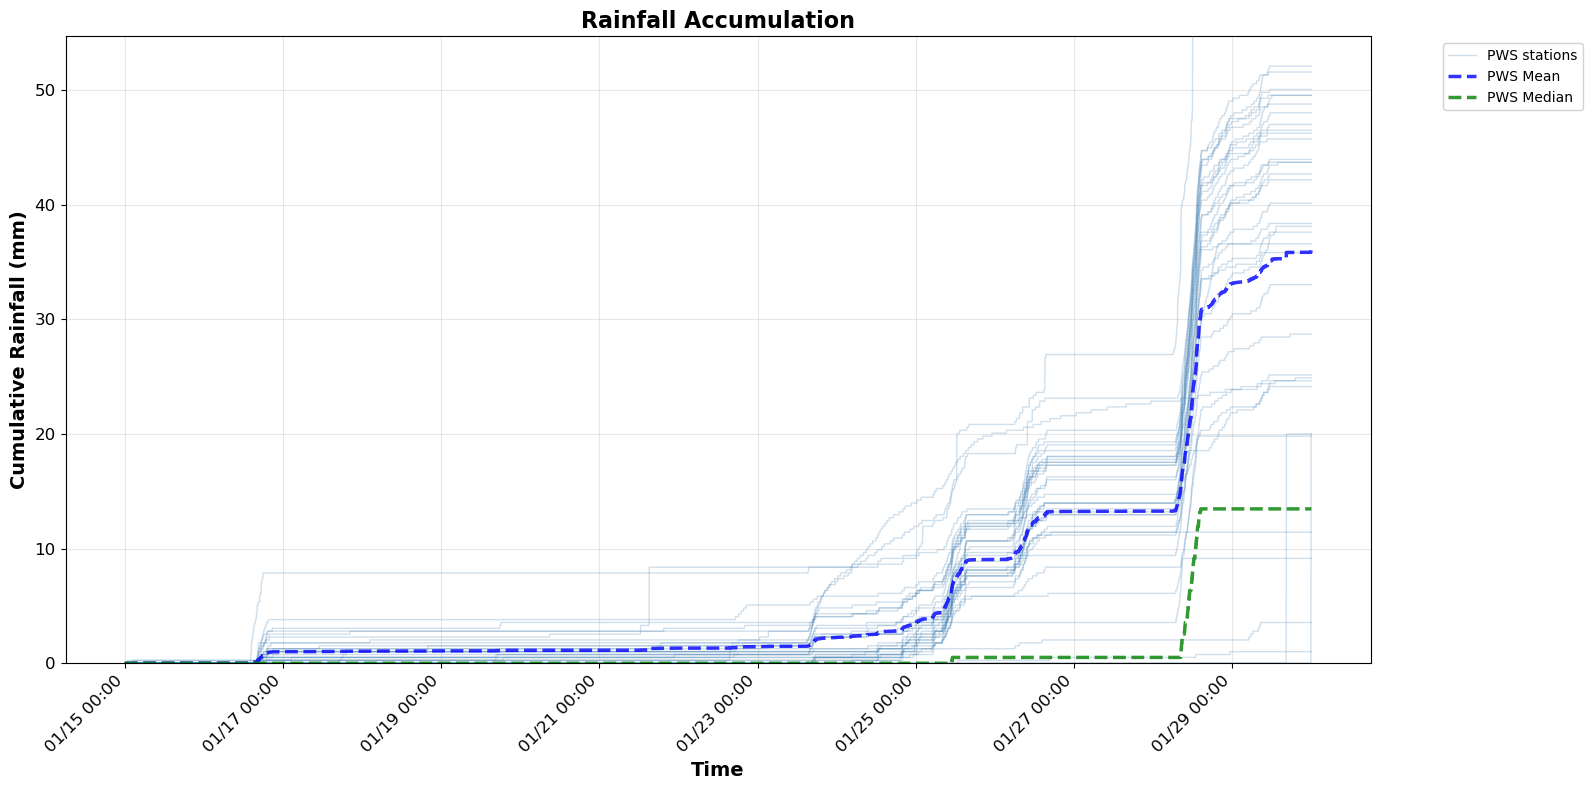

In [42]:
fig, ax = accumulation_plot(
    analysis_data,
    date_range=(START_DATE, END_DATE),
    show_precip_grid=True
)


# PWS only with stats (individuals faded, mean/median visible)
fig, ax = accumulation_plot(
    analysis_data,
    date_range=(START_DATE, END_DATE),
    datasets='pws',
    stats=True
)

## 9. RSL Time Series

Plot Received Signal Level (RSL) time series for specific CML links to visualize signal attenuation patterns.

📅 Date range: 2024-01-15 00:00:00 to 2024-01-29 23:59:00
   Timesteps: 21600


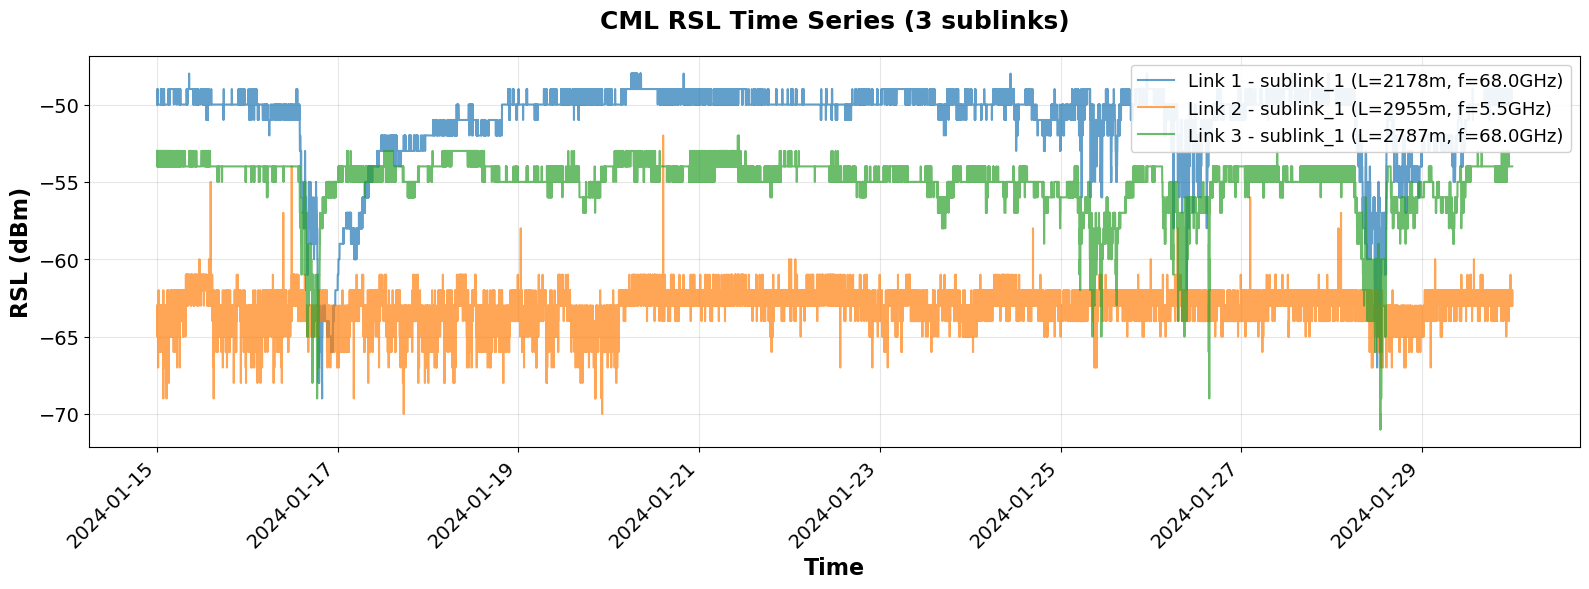

In [43]:
# Plot specific CML links
plot_cml_rsl(
    ds_links,
    cml_ids=['1', '2', '3'],
    sublink_ids='sublink_1',
    date_range=(START_DATE, END_DATE),
    figsize=(16, 6)
)

plt.show()

## 10. Multipanel Plots with Matched Sensors

**Goal:** Choose CML sublinks and plot them with their corresponding PWS stations in a multipanel layout for comparative analysis.

### 10.1. Match CML Links to PWS Stations

Find the nearest PWS stations to each CML link within a specified distance threshold.

In [44]:

# all links 
cml_to_pws, links_meta, pws_meta = find_nearest_pws_stations(
    ds_links=ds_links,
    links_meta=links_meta,
    pws_meta=metadata['wu'],
    cml_ids= None,
    max_distance_km=5.0,
    max_stations=None,
)


ℹ No CML IDs specified - processing all 75 links in dataset

Sample link→PWS matches:
  Link 1: 10 PWS within 5.0km
  Link 2: 10 PWS within 5.0km
  ... and 73 more links

✓ Filtered network: 103 links, 36 PWS stations


In [45]:
# Step 1: Find nearest PWS + get filtered metadata
cml_to_pws_network , links_filtered, pws_filtered = find_nearest_pws_stations(
    ds_links=ds_links,
    links_meta=links_meta,
    pws_meta=metadata['wu'],
    cml_ids= None,
    max_distance_km=5.0,
    max_stations=None,
)
# Step 2: Filter links by criteria (frequency + length)
filtered_links = filter_cml_links(
    df_metadata=links_meta,
    freq_range=(5000, 7000),  # MHz 
    length_range=(3000, 8000)  # meters
)

# Step 3: Get CML IDs from filtered result and validate against dataset
cml_ids_from_meta = list(filtered_links.index)
available_cml_ids = [str(cid) for cid in ds_links.cml_id.values]
cml_ids = [cid for cid in cml_ids_from_meta if str(cid) in available_cml_ids]

# Step 3: Find nearest PWS + get filtered metadata
cml_to_pws_network , links_filtered, pws_filtered = find_nearest_pws_stations(
    ds_links=ds_links,
    links_meta=links_meta,
    pws_meta=metadata['wu'],
    cml_ids=cml_ids,
    max_distance_km=5.0,
    max_stations=None,
)


ℹ No CML IDs specified - processing all 75 links in dataset

Sample link→PWS matches:
  Link 1: 10 PWS within 5.0km
  Link 2: 10 PWS within 5.0km
  ... and 73 more links

✓ Filtered network: 103 links, 36 PWS stations

Sample link→PWS matches:
  Link 19: 11 PWS within 5.0km
  Link 20: 12 PWS within 5.0km
  ... and 2 more links

✓ Filtered network: 7 links, 21 PWS stations


✓ Matplotlib map created


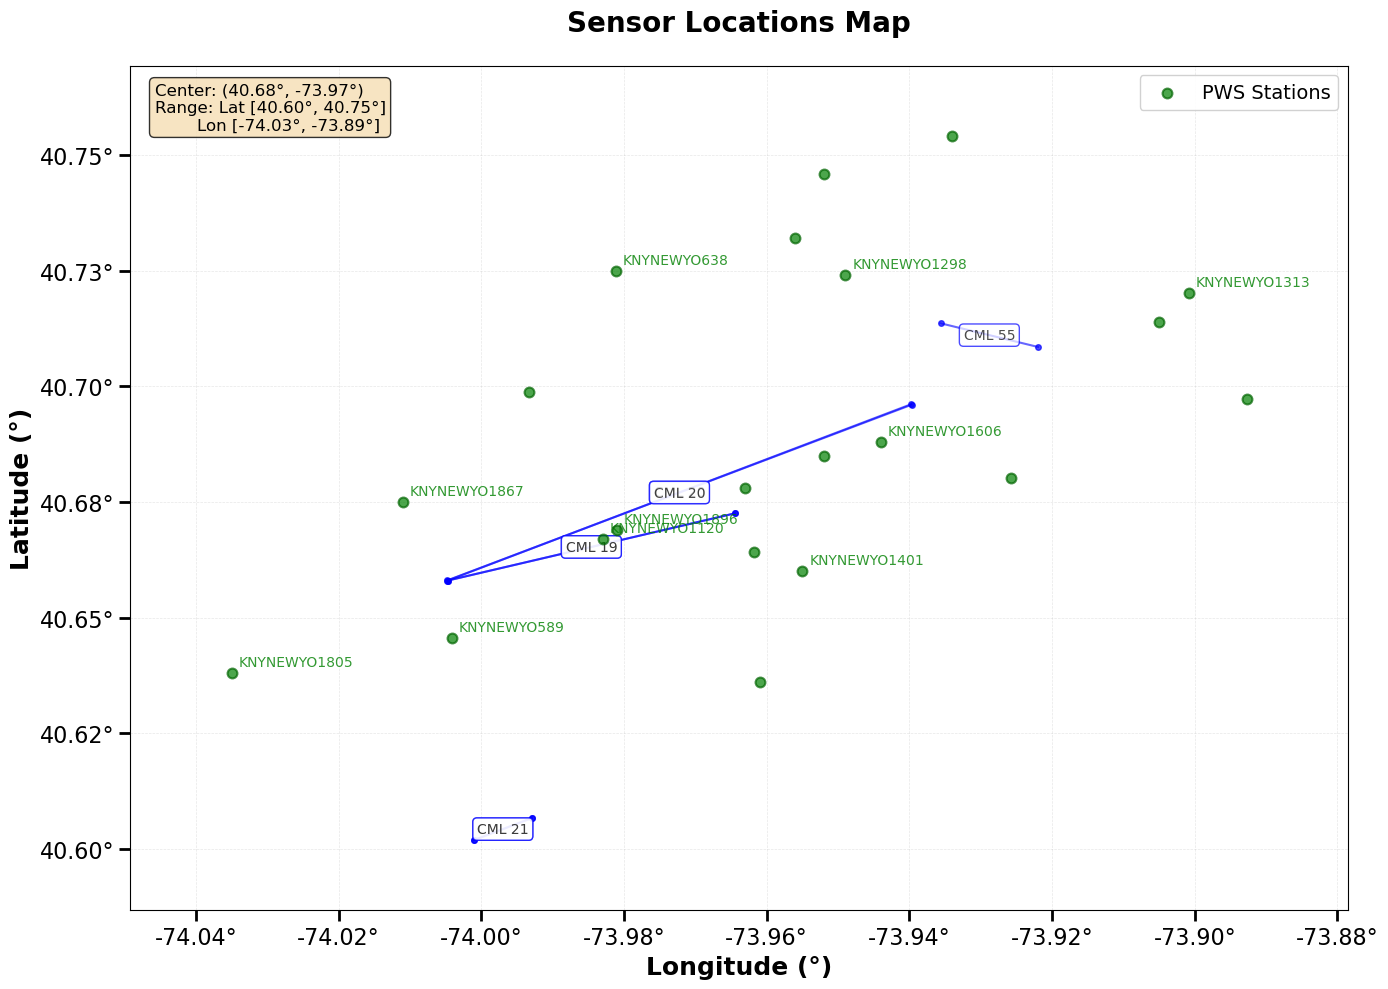

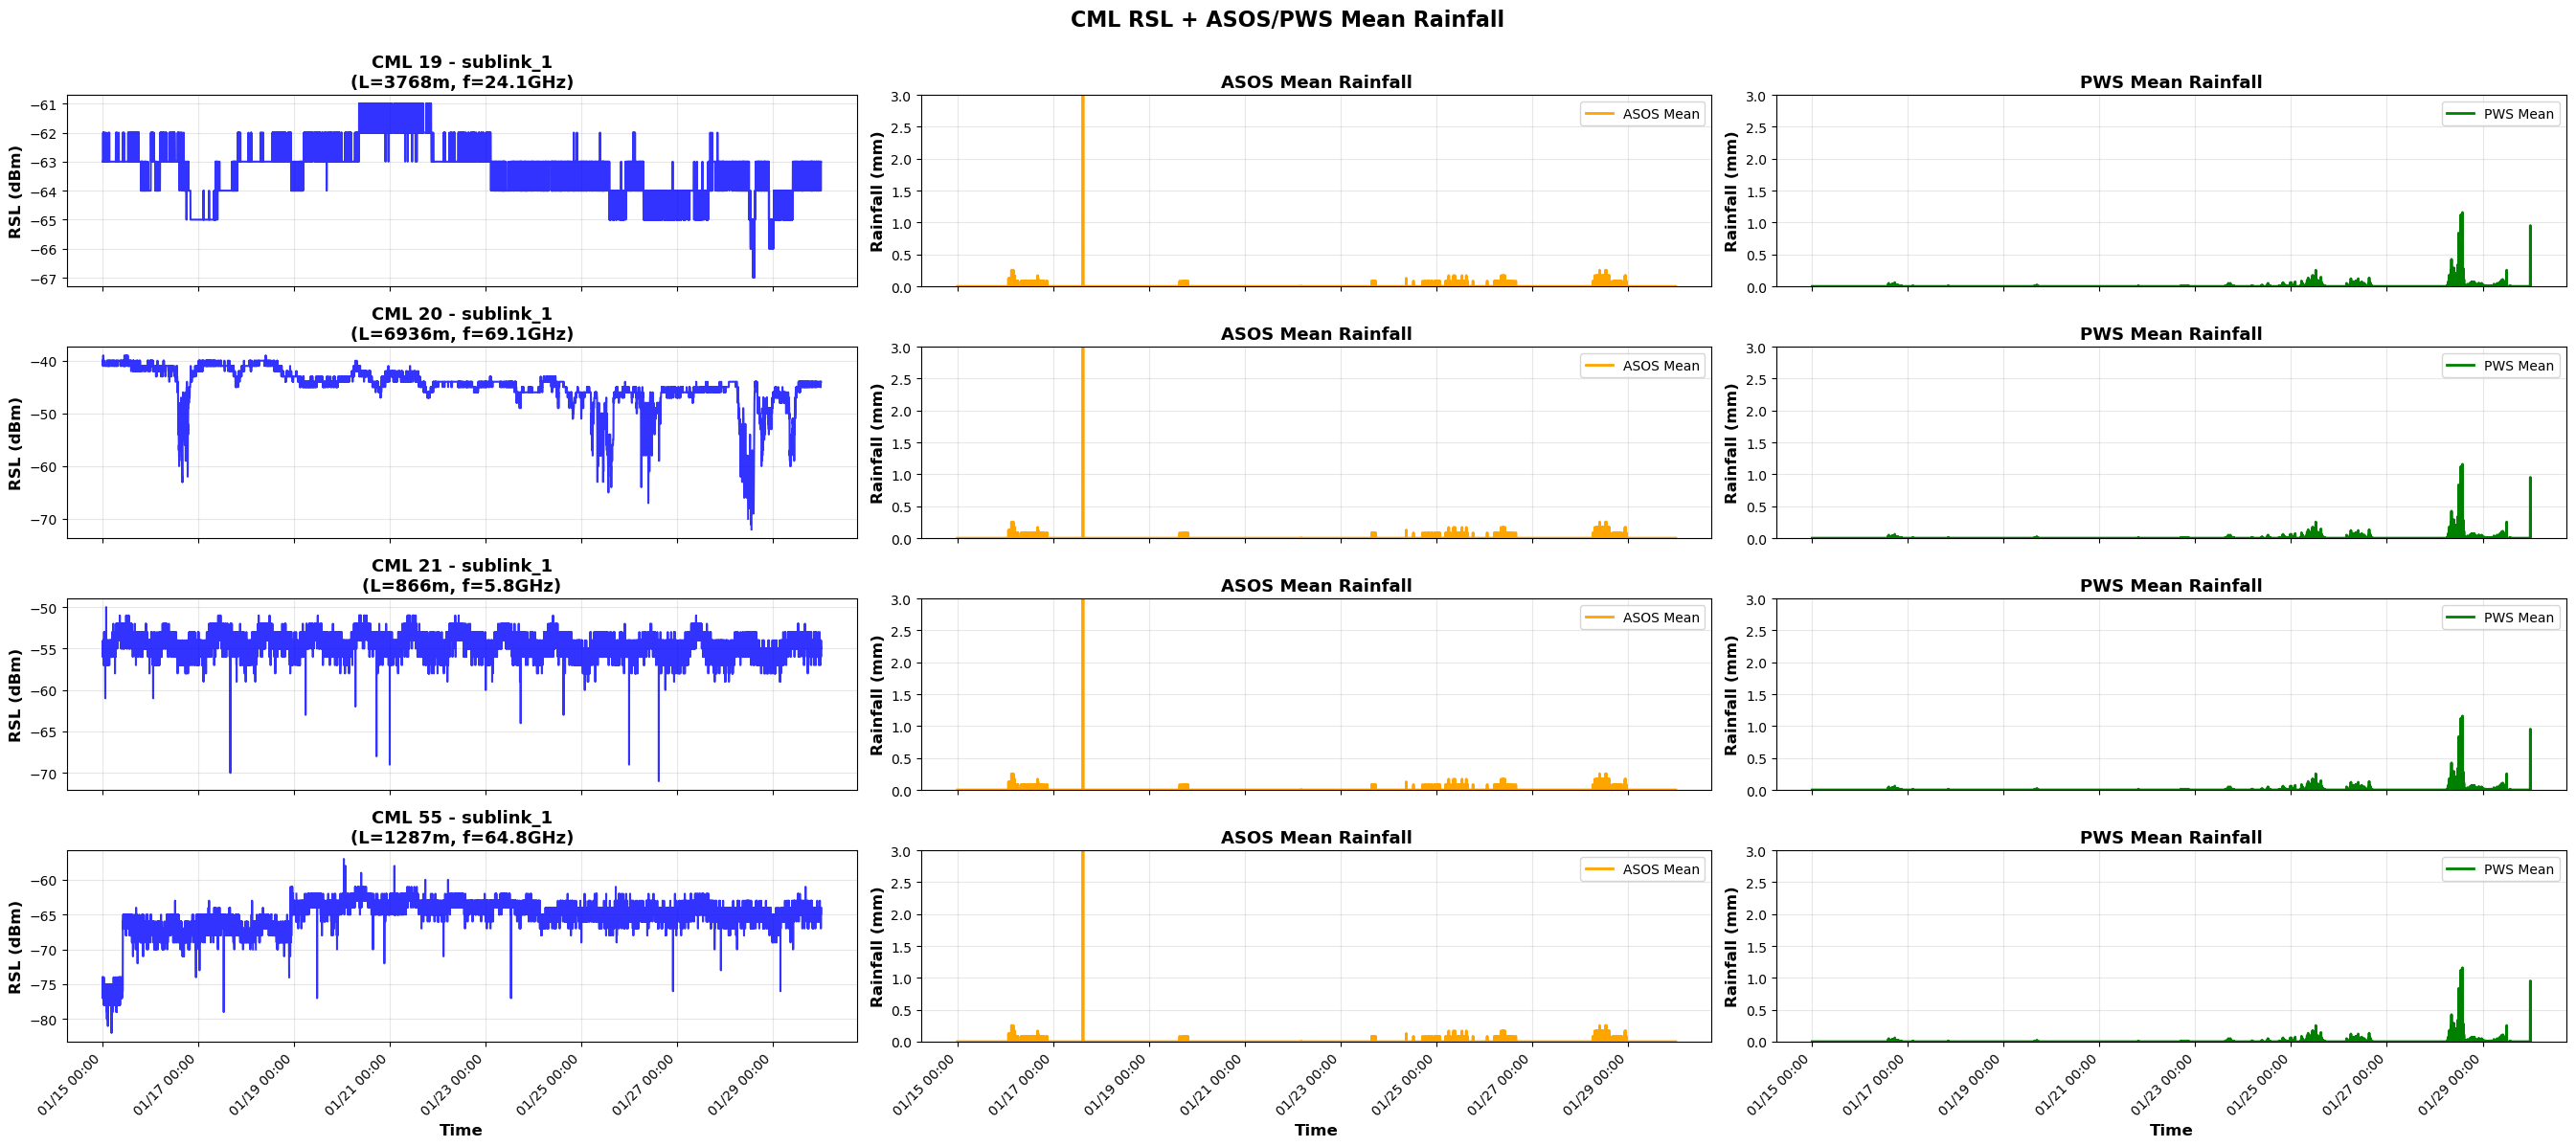

In [46]:
# Step 4: Plot the subnetwork
display_sensors_map(
    links_meta=links_filtered,
    pws_meta=pws_filtered,
    asos_meta=None,
    show_link_labels=True,
    map_type='matplotlib',
)


# Plot CML links and their matched PWS stations
fig, axes = plot_subnetwork(
    ds_links=ds_links, 
    analysis_data=analysis_data, 
    cml_to_pws=cml_to_pws_network,
    sublink_id='sublink_1', 
    date_range=(START_DATE, END_DATE), 
    figsize=(18, 12),
    y_lim=[0, 3]
)
plt.show()
plt.show()

### 10.2. Stacked Layout (All Sublinks + PWS + ASOS)

Create multipanel plots showing all CML sublinks with matched PWS stations and ASOS precipitation data in a stacked vertical or horizontal layout.

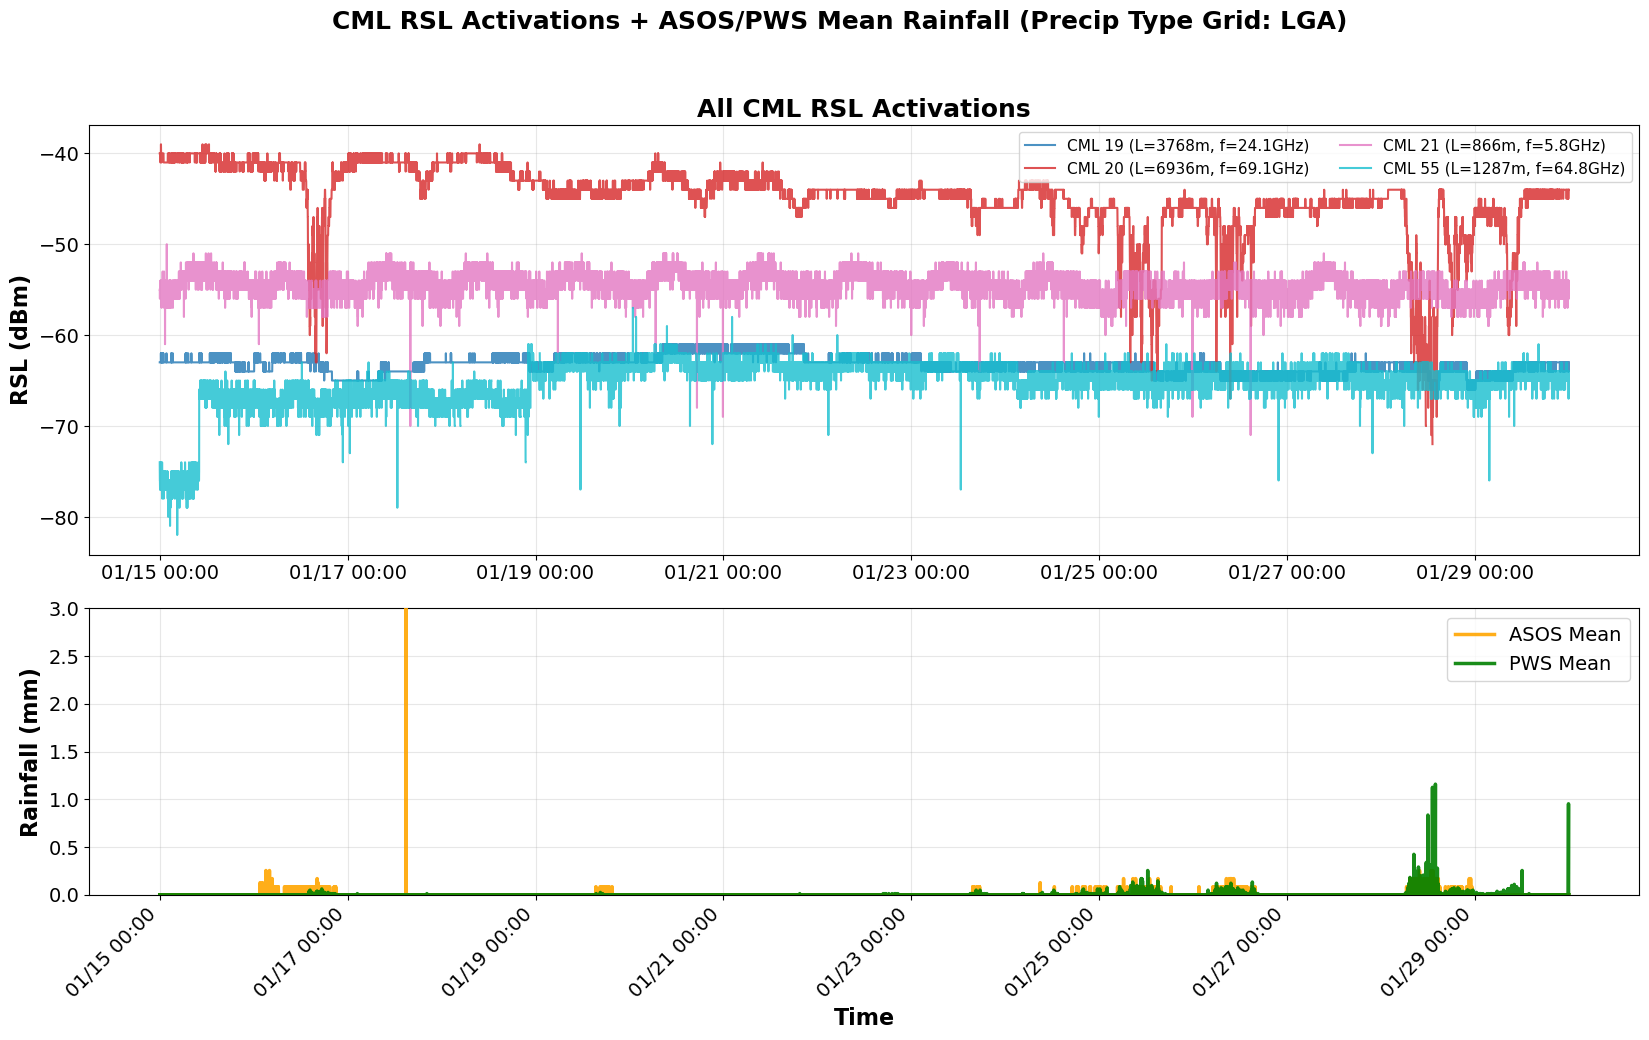

In [47]:

# Vertical
fig, axes = plot_subnetwork(ds_links, analysis_data, cml_to_pws_network,
                           date_range=(START_DATE, END_DATE), plot_type='LGA',
                           layout='vertical', rainfall_source='both')

## 11. Rain Detection: Rolling STD Method

**Steps:**
1. Select CML link and extract RSL data
2. Prepare ground truth rainfall data from matched PWS and ASOS stations
3. Apply rolling standard deviation method for rain event detection
4. Compare CML detection results with ground truth measurements

Combine rainfall measurements from matched PWS and ASOS stations for validation of CML-based rain detection.


✓ Detection: 406 periods (14.6%) | threshold=1.0 dB


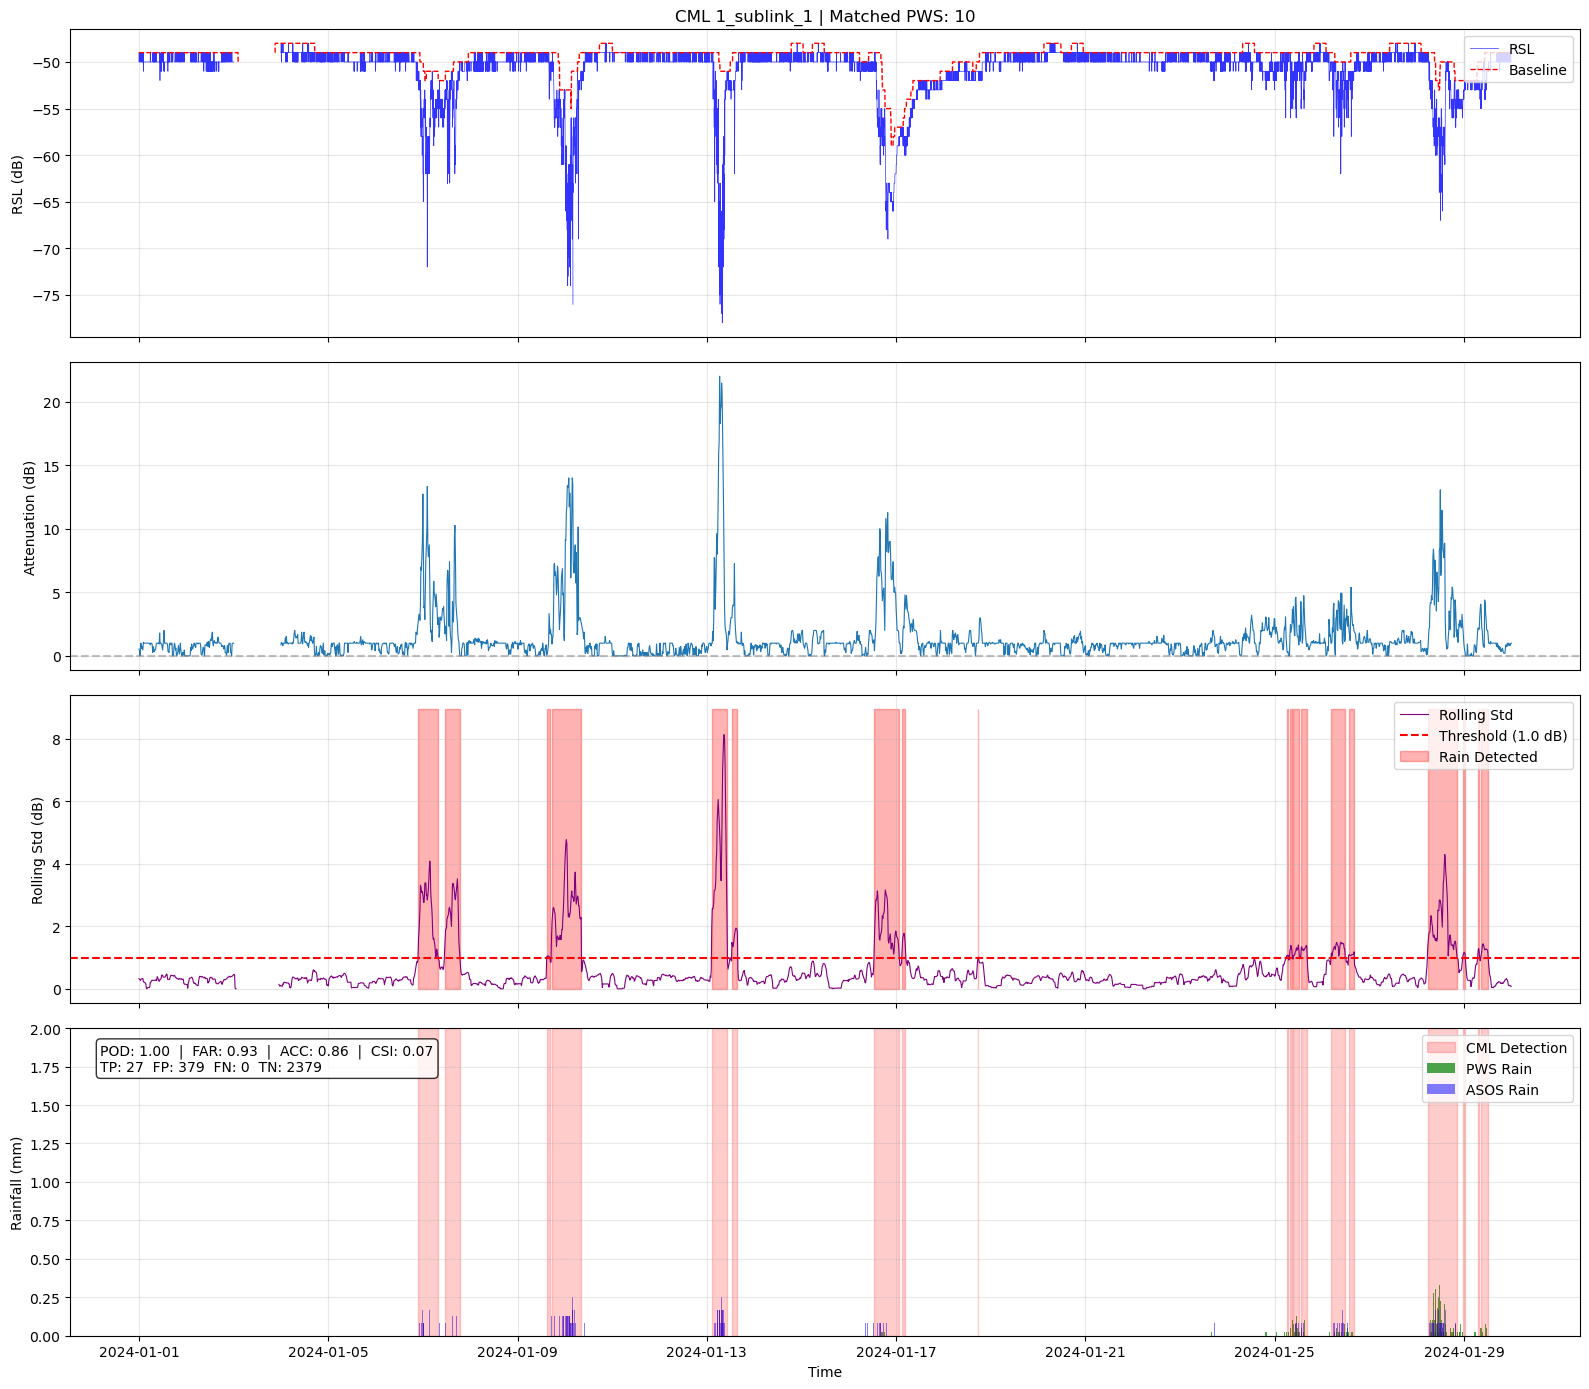


DETECTION METRICS
  POD (Hit Rate):     100.00%
  FAR (False Alarm):  93.35%
  Accuracy:           86.39%
  CSI (Threat Score): 6.65%


In [49]:
# ============================================================================
# RAIN DETECTION (Rolling Std Method)
# ============================================================================
START_DATE = datetime(2024, 1, 1)
END_DATE   = datetime(2024, 1, 30)
# --- PARAMETERS ---
CML_ID = '1'
SUBLINK_ID = 'sublink_1'

BASELINE_WINDOW = '6h'
BASELINE_METHOD = 'max'

DETECTION_WINDOW = '3h'
THRESHOLD = 1.0
RESAMPLE = '15min'

RAIN_Y_MAX = 2.0     # Max y-axis for rainfall (None for auto).
SHOW_METRICS = True  # Show metrics on plot (True/False).

# --- RUN ---
df_cml, df_pws_rain, df_asos_rain, matched_pws = prepare_detection_data(
    analysis_data, CML_ID, SUBLINK_ID, cml_to_pws,
    baseline_window=BASELINE_WINDOW,
    baseline_method=BASELINE_METHOD
)

df_detection = run_rolling_std_detection(
    df_cml, window=DETECTION_WINDOW, threshold=THRESHOLD, resample=RESAMPLE
)

plot_detection_results(
    df_cml, df_detection, df_pws_rain, df_asos_rain,
    title=f'CML {CML_ID}_{SUBLINK_ID} | Matched PWS: {len(matched_pws)}',
    start_date=START_DATE,
    end_date=END_DATE,
    rain_y_max=RAIN_Y_MAX,
    show_metrics=SHOW_METRICS
)

---
## Done!

**Key Features:**
1. ✅ Load/fetch ASOS and WU data
2. ✅ Load OpenMesh CML and PWS data
3. ✅ Prepare analysis-ready datasets
4. ✅ Interactive maps with sensor filtering
5. ✅ Quick comparison plots
6. ✅ CML activation plots
7. ✅ Multipanel plots with matched CML-PWS sensors
8. ✅ **Rain event detection with validation against ground truth**

**Next Steps:**
- Customize CML and PWS selections
- Adjust distance threshold for matching
- Try different parameters (temperature, humidity, etc.)
- Tune detection thresholds for better accuracy
- Export figures and data
